# Advanto Social Network Analysis
**Course: Social Networks in Organizations — Group Project**

Three datasets:
1. **Demographics** – individual attributes of the 26 managers
2. **Event attendance** – bipartite manager × event participation matrix
3. **Communication network** – directed work-communication ties

In [59]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import warnings
import seaborn as sns 
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [36]:
demo   = pd.read_csv('manager_demographics.csv')
events = pd.read_csv('event_attendance.csv').set_index('Manager')
edges  = pd.read_csv('communication_network.csv')

# pandas reads 'None' strings as NaN — restore as a label
demo['Legacy_Organization'] = demo['Legacy_Organization'].fillna('Post-merger')
demo['Favor_Merger']        = demo['Favor_Merger'].fillna('N/A')

print('Demographics:', demo.shape)
print('Events:', events.shape)
print('Edges:', edges.shape)
demo.head()

Demographics: (26, 8)
Events: (26, 8)
Edges: (102, 2)


,Manager,Gender,Age,Education,Legacy_Organization,Self_Monitoring,Brokerage_Orientation,Favor_Merger
0,1,F,30,MBA,Post-merger,5,TI,N/A
1,2,F,25,MSc,Brightway,2,TG,Y
2,3,M,40,MSc,Genesisphere,1,TG,Y
3,4,F,42,MBA,Post-merger,3,TI,N/A
4,5,F,54,MSc,Brightway,4,TG,Y


## 2. Demographics Analysis

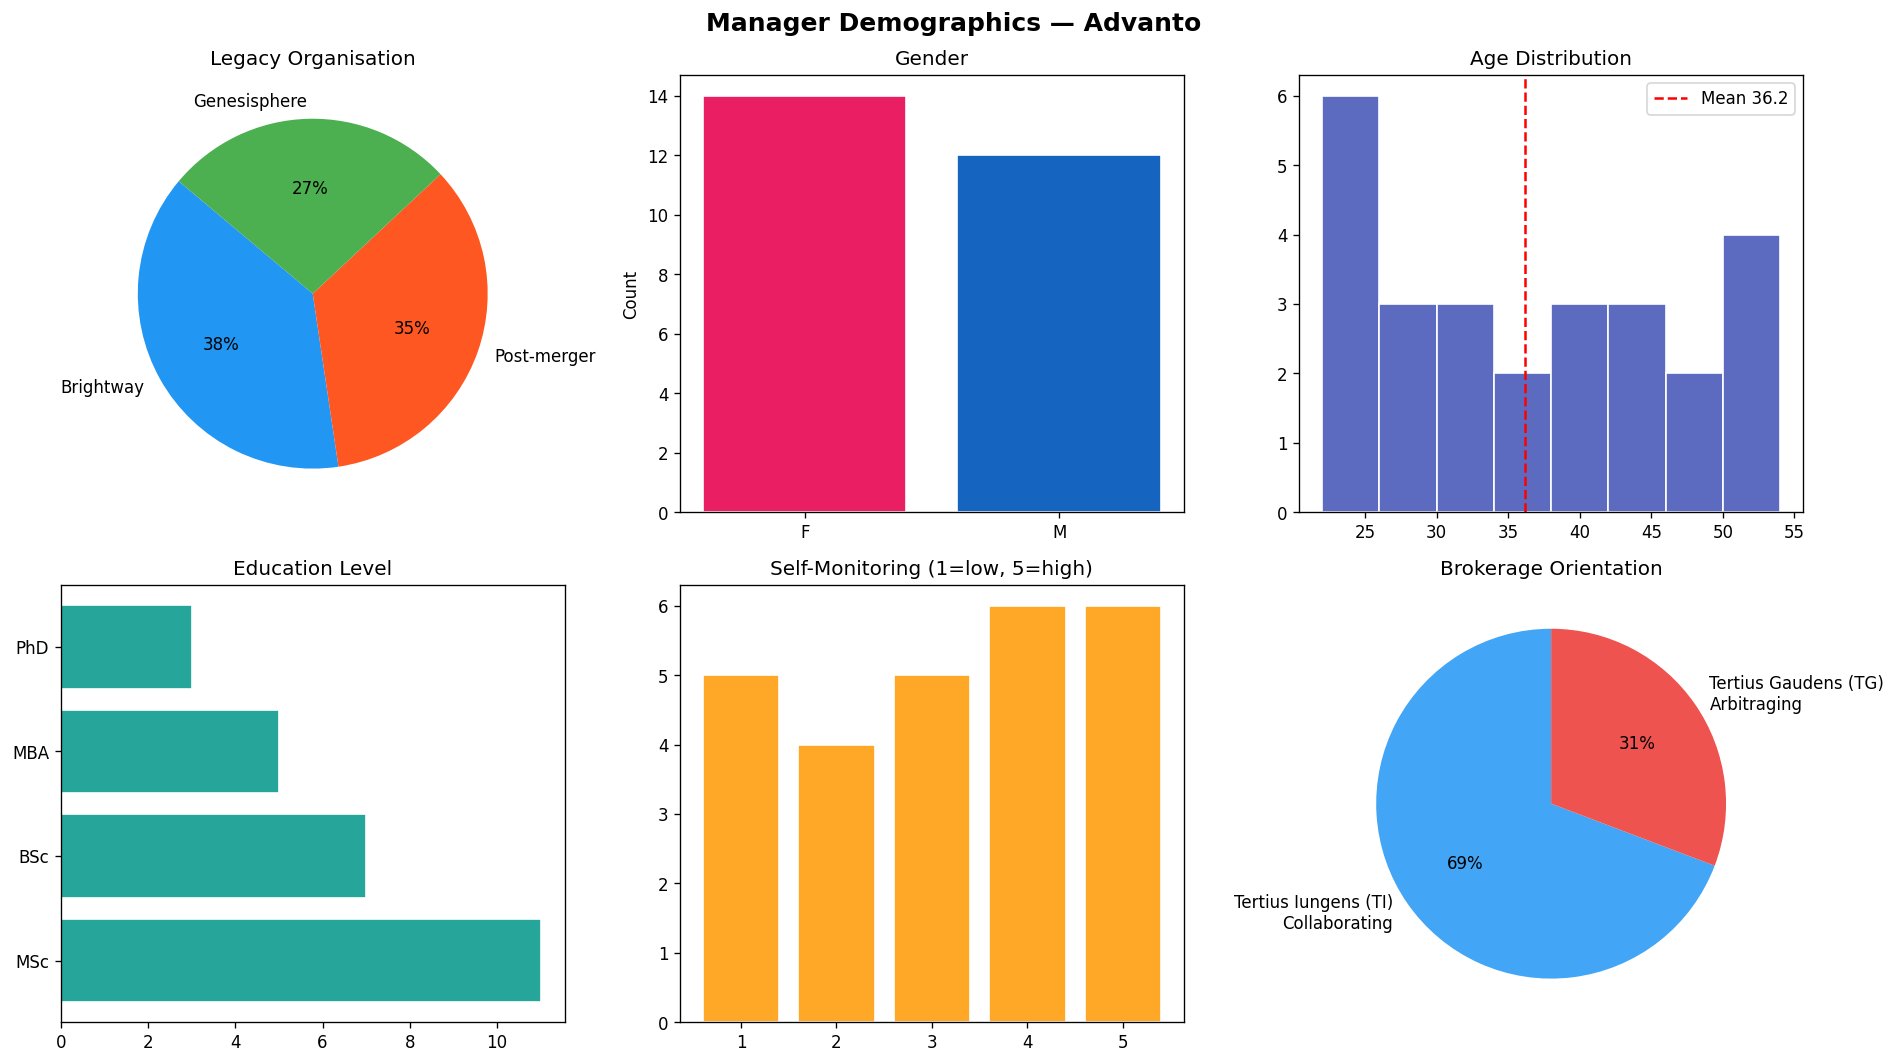

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Manager Demographics — Advanto', fontsize=15, fontweight='bold')

# Legacy organisation
lc = demo['Legacy_Organization'].value_counts()
axes[0,0].pie(lc, labels=lc.index, autopct='%1.0f%%',
              colors=['#2196F3','#FF5722','#4CAF50','#9E9E9E'], startangle=140)
axes[0,0].set_title('Legacy Organisation')

# Gender
gc = demo['Gender'].value_counts()
axes[0,1].bar(gc.index, gc.values, color=['#E91E63','#1565C0'], edgecolor='white')
axes[0,1].set_title('Gender')
axes[0,1].set_ylabel('Count')

# Age
axes[0,2].hist(demo['Age'], bins=8, color='#5C6BC0', edgecolor='white')
axes[0,2].axvline(demo['Age'].mean(), color='red', linestyle='--',
                  label=f'Mean {demo["Age"].mean():.1f}')
axes[0,2].set_title('Age Distribution')
axes[0,2].legend()

# Education
ec = demo['Education'].value_counts()
axes[1,0].barh(ec.index, ec.values, color='#26A69A', edgecolor='white')
axes[1,0].set_title('Education Level')

# Self-monitoring
sm = demo['Self_Monitoring'].value_counts().sort_index()
axes[1,1].bar(sm.index.astype(str), sm.values, color='#FFA726', edgecolor='white')
axes[1,1].set_title('Self-Monitoring (1=low, 5=high)')

# Brokerage orientation
bo = demo['Brokerage_Orientation'].value_counts()
axes[1,2].pie(bo, labels=['Tertius Iungens (TI)\nCollaborating',
                           'Tertius Gaudens (TG)\nArbitraging'],
              autopct='%1.0f%%', colors=['#42A5F5','#EF5350'], startangle=90)
axes[1,2].set_title('Brokerage Orientation')

plt.tight_layout()
plt.savefig('demographics_overview.png', bbox_inches='tight')
plt.show()

Merger support by legacy org:
Favor_Merger         N  Y
Legacy_Organization      
Brightway            3  7
Genesisphere         5  2

Percentages:
Favor_Merger            N     Y
Legacy_Organization            
Brightway            30.0  70.0
Genesisphere         71.4  28.6


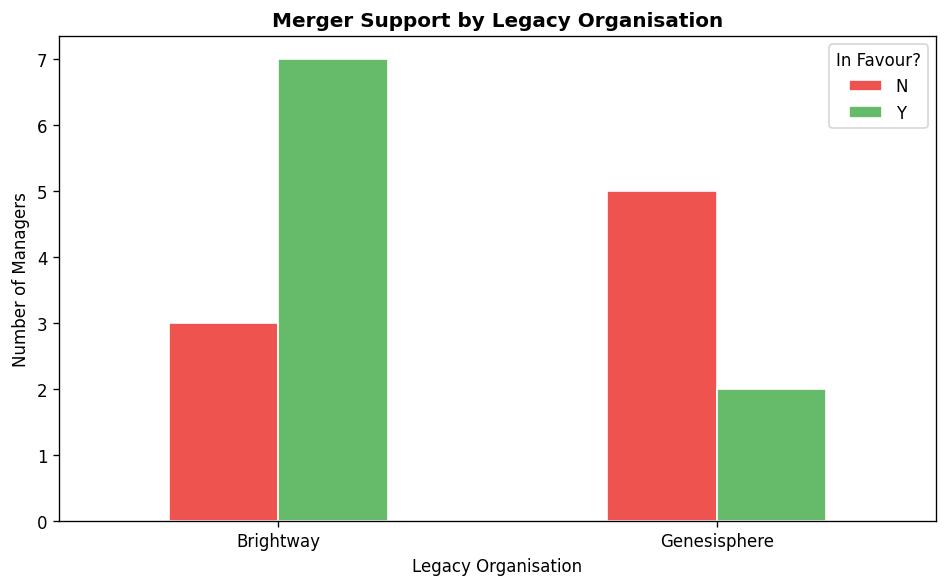

In [38]:
# Merger support by legacy org
favor = demo[(demo['Legacy_Organization'] != 'None') & (demo['Favor_Merger'] != 'N/A')].copy()
cross = pd.crosstab(favor['Legacy_Organization'], favor['Favor_Merger'])
print('Merger support by legacy org:')
print(cross)
print()
print('Percentages:')
print((cross.div(cross.sum(axis=1), axis=0) * 100).round(1))

fig, ax = plt.subplots(figsize=(8, 5))
cross.plot(kind='bar', ax=ax, color=['#EF5350','#66BB6A'], edgecolor='white', rot=0)
ax.set_title('Merger Support by Legacy Organisation', fontweight='bold')
ax.set_xlabel('Legacy Organisation')
ax.set_ylabel('Number of Managers')
ax.legend(title='In Favour?')
plt.tight_layout()
plt.savefig('merger_support.png', bbox_inches='tight')
plt.show()

## 3. Event Attendance — Bipartite Network

In [39]:
events_total = events.sum(axis=1).rename('events_attended')
demo = demo.merge(events_total.reset_index(), on='Manager')

print('Events attended per manager:')
print(events_total.describe().round(2))
print(f'\nManagers attending 0 events: {(events_total == 0).sum()}')
print('\nAttendance per event:')
print(events.sum(axis=0))

Events attended per manager:
count    26.00
mean      1.31
std       0.97
min       0.00
25%       1.00
50%       1.00
75%       2.00
max       3.00
Name: events_attended, dtype: float64

Managers attending 0 events: 6

Attendance per event:
E1    5
E2    5
E3    4
E4    3
E5    3
E6    5
E7    6
E8    3
dtype: int64


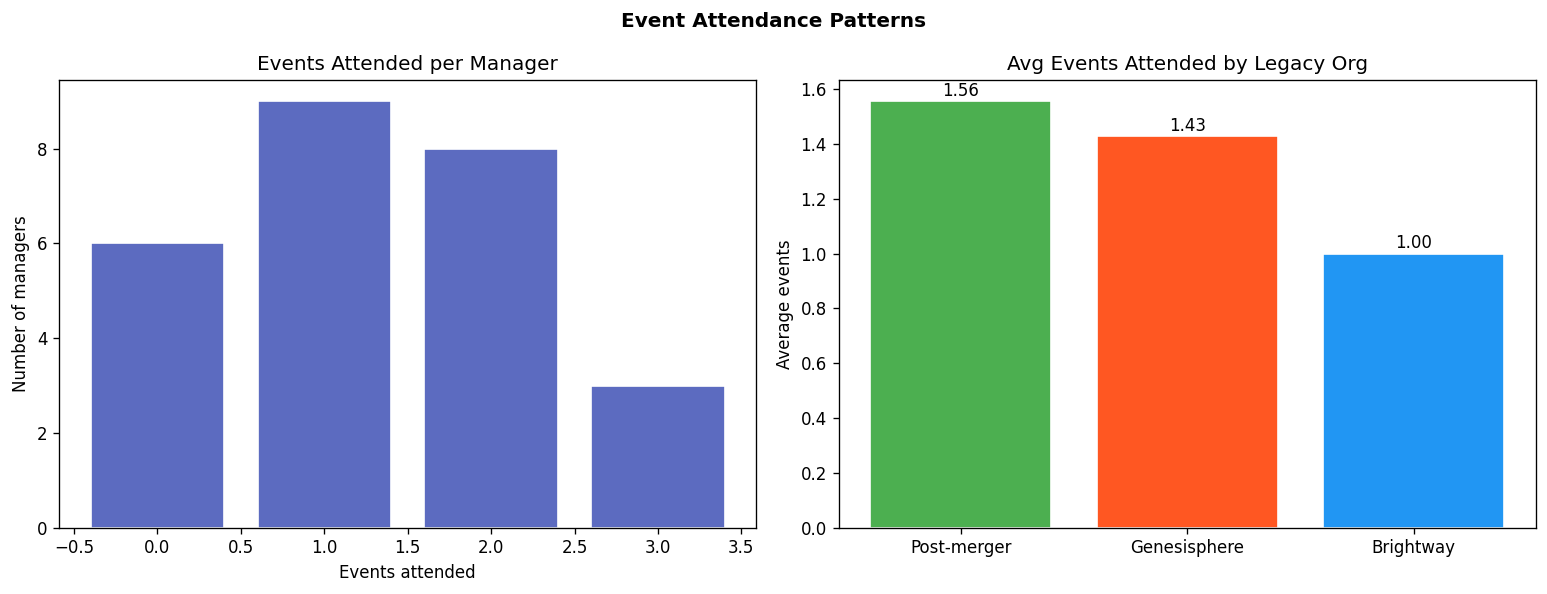

In [58]:
legacy_lookup = dict(zip(demo['Manager'], demo['Legacy_Organization']))
color_map_leg = {'Brightway':'#2196F3','Genesisphere':'#FF5722','Post-merger':'#4CAF50'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Event Attendance Patterns', fontweight='bold')

vc = events_total.value_counts().sort_index()
axes[0].bar(vc.index, vc.values, color='#5C6BC0', edgecolor='white')
axes[0].set_title('Events Attended per Manager')
axes[0].set_xlabel('Events attended')
axes[0].set_ylabel('Number of managers')

la = demo.groupby('Legacy_Organization')['events_attended'].mean().sort_values(ascending=False)
bars = axes[1].bar(la.index, la.values,
                   color=[color_map_leg.get(x,'grey') for x in la.index], edgecolor='white')
axes[1].set_title('Avg Events Attended by Legacy Org')
axes[1].set_ylabel('Average events')
for bar, val in zip(bars, la.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.2f}', ha='center')

plt.tight_layout()
plt.savefig('event_attendance.png', bbox_inches='tight')
plt.show()

In [41]:
# Build bipartite graph
from networkx.algorithms import bipartite

B = nx.Graph()
managers_list = [f'M{i}' for i in range(1, 27)]
event_nodes   = events.columns.tolist()
B.add_nodes_from(managers_list, bipartite=0)
B.add_nodes_from(event_nodes, bipartite=1)

for mgr_id, row in events.iterrows():
    for evt, val in row.items():
        if val == 1:
            B.add_edge(f'M{mgr_id}', evt)

# Co-attendance projection
co_attend = bipartite.weighted_projected_graph(B, set(managers_list))

cross_leg = sum(1 for u, v in co_attend.edges()
                if legacy_lookup.get(int(u[1:]),'?') != legacy_lookup.get(int(v[1:]),'?')
                and legacy_lookup.get(int(u[1:]),'?') != 'None'
                and legacy_lookup.get(int(v[1:]),'?') != 'None')
print(f'Co-attendance network: {co_attend.number_of_nodes()} nodes, {co_attend.number_of_edges()} edges')
print(f'Cross-legacy co-attendance ties: {cross_leg}')

Co-attendance network: 26 nodes, 55 edges
Cross-legacy co-attendance ties: 33


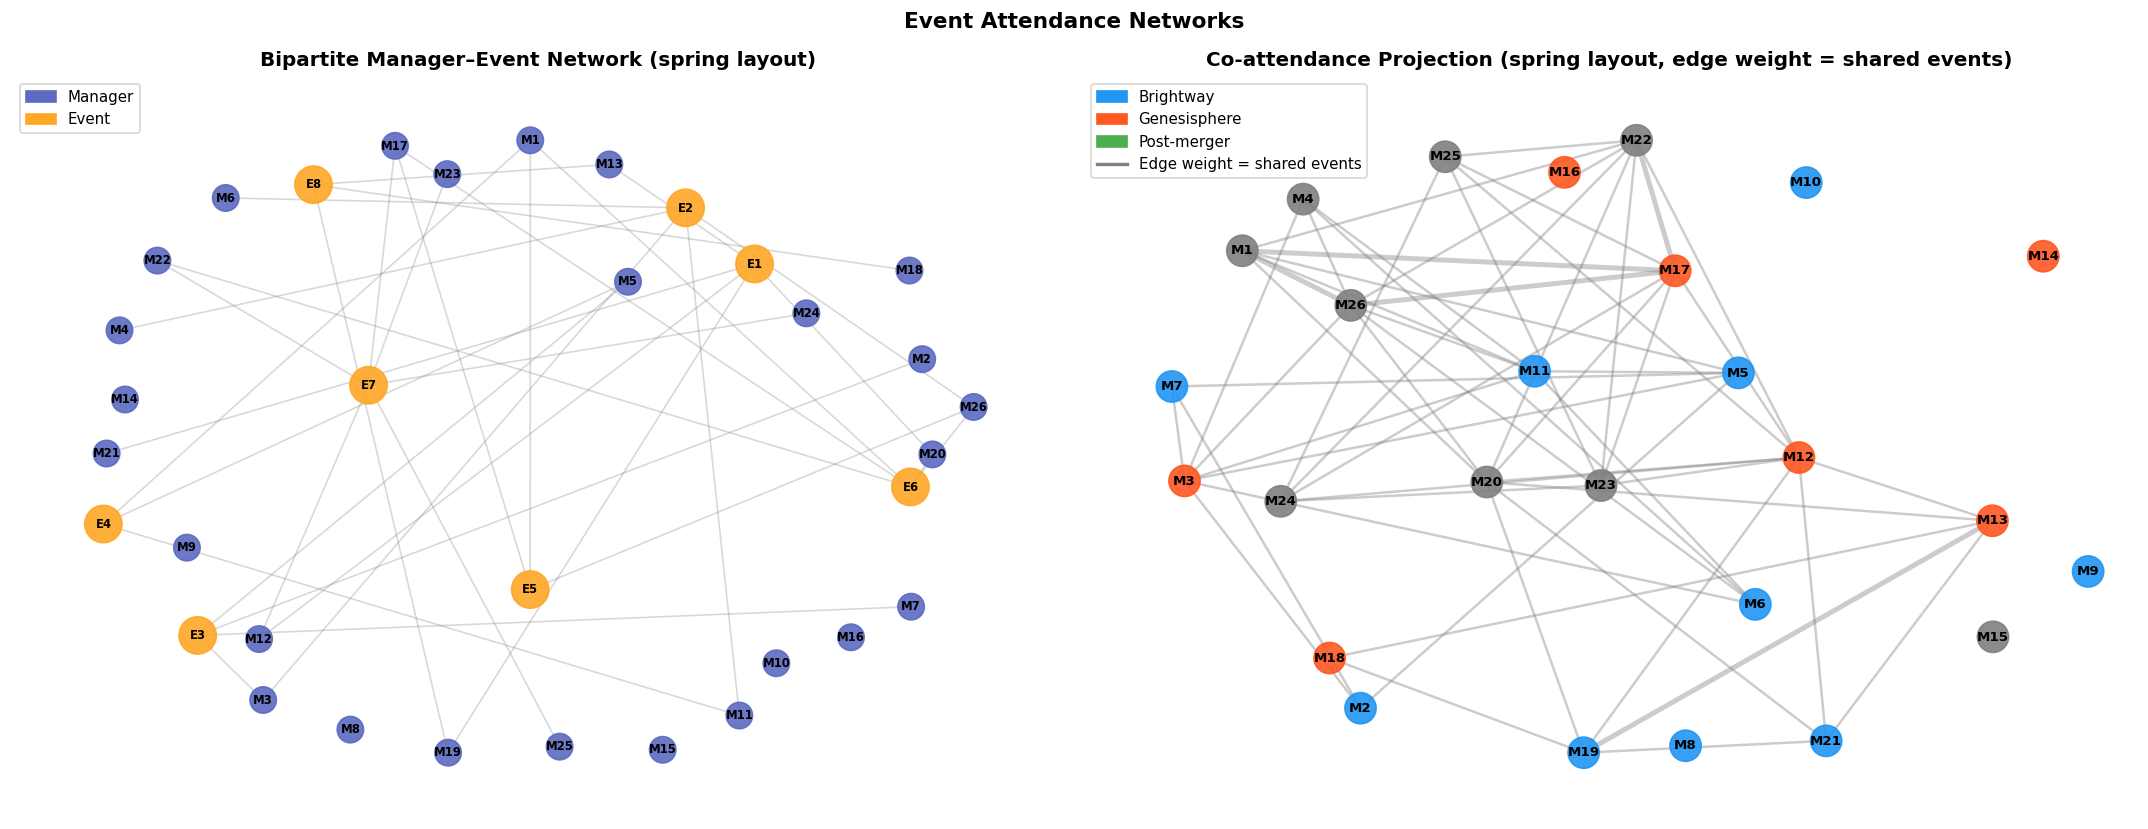

In [42]:

# --- Bipartite network: spring layout ---
manager_nodes = [n for n, d in B.nodes(data=True) if d.get('bipartite') == 0]
event_nodes_b = [n for n, d in B.nodes(data=True) if d.get('bipartite') == 1]

pos_B = nx.spring_layout(B, seed=42, k=2.0)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Event Attendance Networks', fontsize=13, fontweight='bold')

# Bipartite graph
node_colors_B = ['#5C6BC0' if n in manager_nodes else '#FFA726' for n in B.nodes()]
node_sizes_B  = [250 if n in manager_nodes else 500 for n in B.nodes()]
nx.draw_networkx_edges(B, pos_B, alpha=0.3, edge_color='grey', ax=axes[0])
nx.draw_networkx_nodes(B, pos_B, node_color=node_colors_B, node_size=node_sizes_B,
                       alpha=0.9, ax=axes[0])
nx.draw_networkx_labels(B, pos_B, font_size=7, font_weight='bold', ax=axes[0])
axes[0].legend(handles=[
    mpatches.Patch(color='#5C6BC0', label='Manager'),
    mpatches.Patch(color='#FFA726', label='Event'),
], loc='upper left', fontsize=9)
axes[0].set_title('Bipartite Manager–Event Network (spring layout)', fontweight='bold')
axes[0].axis('off')

# Co-attendance projection
pos_co = nx.spring_layout(co_attend, seed=42, k=2.0)
edge_weights = [co_attend[u][v]['weight'] for u, v in co_attend.edges()]
node_colors_co = [node_color(int(n[1:])) for n in co_attend.nodes()]
nx.draw_networkx_edges(co_attend, pos_co, width=[w * 1.5 for w in edge_weights],
                       alpha=0.4, edge_color='grey', ax=axes[1])
nx.draw_networkx_nodes(co_attend, pos_co, node_color=node_colors_co, node_size=350,
                       alpha=0.9, ax=axes[1])
nx.draw_networkx_labels(co_attend, pos_co, font_size=8, font_weight='bold', ax=axes[1])
axes[1].legend(handles=[
    mpatches.Patch(color='#2196F3', label='Brightway'),
    mpatches.Patch(color='#FF5722', label='Genesisphere'),
    mpatches.Patch(color='#4CAF50', label='Post-merger'),
    Line2D([0],[0], color='grey', linewidth=2, label='Edge weight = shared events'),
], loc='upper left', fontsize=9)
axes[1].set_title('Co-attendance Projection (spring layout, edge weight = shared events)',
                  fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('bipartite_coattendance.png', bbox_inches='tight')
plt.show()


1. calculate on avg. person from Brightway with how many people from Brightway at event, how many from Genesisphere... 
2. risolvere problema colore 

## 4. Communication Network — Core Analysis

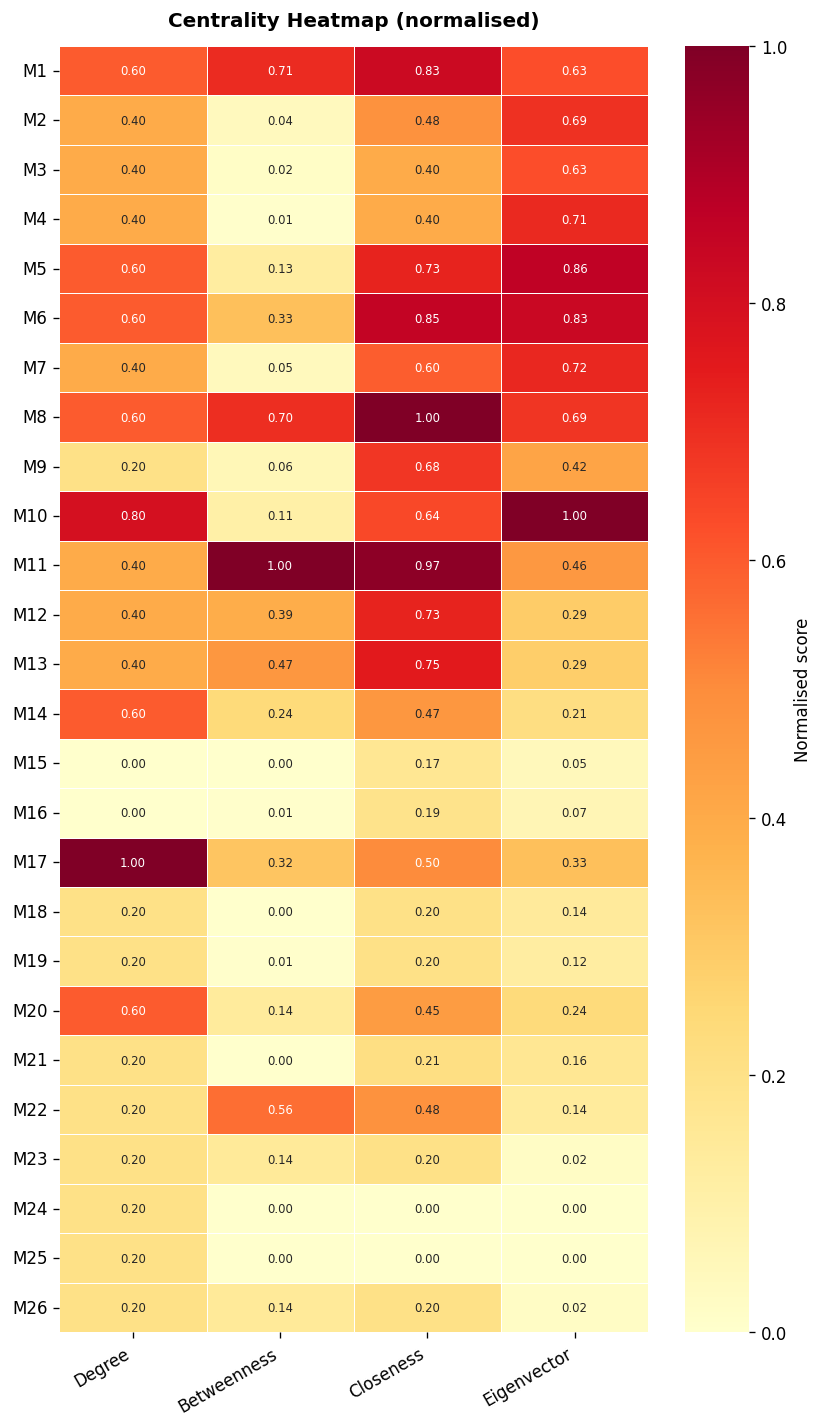

In [60]:
import seaborn as sns

metrics = ['Degree', 'Betweenness', 'Closeness', 'Eigenvector']
heat_df = centrality_df.set_index('Manager')[metrics]
norm_heat = (heat_df - heat_df.min()) / (heat_df.max() - heat_df.min())
norm_heat.index = [f'M{i}' for i in norm_heat.index]

fig, ax = plt.subplots(figsize=(7, 12))
sns.heatmap(norm_heat, cmap='YlOrRd', linewidths=0.4, linecolor='white',
            annot=True, fmt='.2f', annot_kws={'size': 7},
            cbar_kws={'label': 'Normalised score'}, ax=ax)
ax.set_title('Centrality Heatmap (normalised)', fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('centrality_heatmap.png', bbox_inches='tight')
plt.show()


In [44]:
# Centrality measures
deg_in    = dict(G_dir.in_degree())
deg_out   = dict(G_dir.out_degree())
deg_total = dict(G.degree())
between   = nx.betweenness_centrality(G, normalized=True)
closeness = nx.closeness_centrality(G)
eigenvec  = nx.eigenvector_centrality(G, max_iter=500)
constraint_vals = nx.constraint(G)

centrality_df = pd.DataFrame({
    'Manager':    list(G.nodes()),
    'Degree':     [deg_total[n] for n in G.nodes()],
    'In_Degree':  [deg_in.get(n, 0) for n in G.nodes()],
    'Out_Degree': [deg_out.get(n, 0) for n in G.nodes()],
    'Betweenness':[between[n]   for n in G.nodes()],
    'Closeness':  [closeness[n] for n in G.nodes()],
    'Eigenvector':[eigenvec[n]  for n in G.nodes()],
    'Constraint': [constraint_vals[n] for n in G.nodes()],
})
centrality_df = (centrality_df
                 .sort_values('Manager')
                 .merge(demo[['Manager','Legacy_Organization','Brokerage_Orientation',
                               'Self_Monitoring','Favor_Merger','events_attended']], on='Manager')
                 .reset_index(drop=True))

print('Top 10 by Betweenness:')
print(centrality_df.sort_values('Betweenness', ascending=False)[
    ['Manager','Legacy_Organization','Degree','Betweenness','Closeness','Constraint']
].head(10).round(4).to_string(index=False))

Top 10 by Betweenness:
 Manager Legacy_Organization  Degree  Betweenness  Closeness  Constraint
      11           Brightway       4       0.5000     0.3846      0.3753
       1         Post-merger       5       0.3556     0.3571      0.2888
       8           Brightway       5       0.3514     0.3906      0.3339
      22         Post-merger       3       0.2811     0.2907      0.3333
      13        Genesisphere       4       0.2339     0.3425      0.4319
      12        Genesisphere       4       0.1972     0.3378      0.4319
       6           Brightway       5       0.1664     0.3623      0.3609
      17        Genesisphere       7       0.1586     0.2941      0.3017
      14        Genesisphere       5       0.1214     0.2874      0.2848
      26         Post-merger       3       0.0733     0.2358      0.5062


### 4.1 Network Visualisation

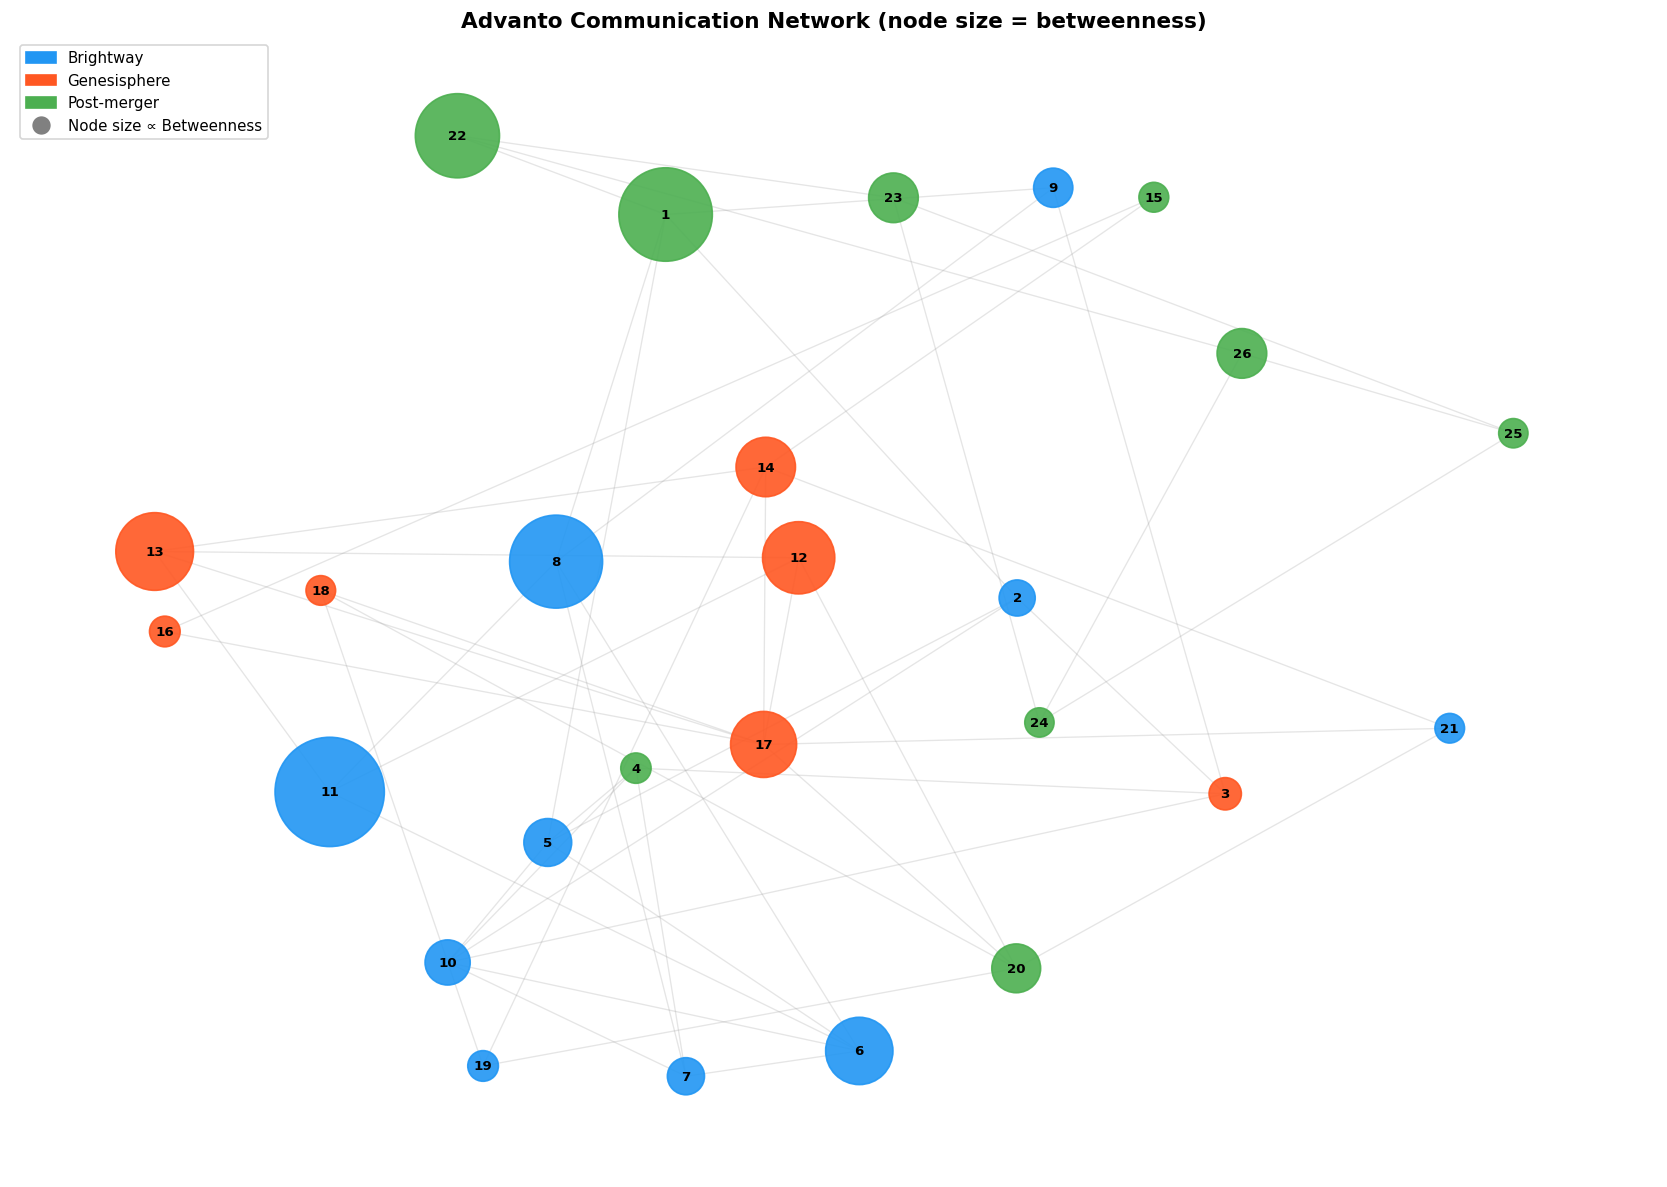

In [61]:
def node_color(mid):
    return color_map_leg.get(legacy_lookup.get(mid, 'None'), 'grey')

node_color_list = [node_color(n) for n in G.nodes()]
node_size_list  = [300 + between[n] * 8000 for n in G.nodes()]
pos = nx.spring_layout(G, seed=42, k=1.5)

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_edges(G, pos, alpha=0.25, edge_color='#999', ax=ax, width=0.8)
nx.draw_networkx_nodes(G, pos, node_color=node_color_list,
                       node_size=node_size_list, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)
legend_els = [
    mpatches.Patch(color='#2196F3', label='Brightway'),
    mpatches.Patch(color='#FF5722', label='Genesisphere'),
    mpatches.Patch(color='#4CAF50', label='Post-merger'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='grey',
           markersize=12, label='Node size ∝ Betweenness'),
]
ax.legend(handles=legend_els, loc='upper left', fontsize=9)
ax.set_title('Advanto Communication Network (node size = betweenness)',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('communication_network.png', bbox_inches='tight')
plt.show()

### 4.2 Legacy Clustering — E-I Index

In [47]:
# Count within vs cross-legacy ties
within_bw, within_gs, cross_ties, other = 0, 0, 0, 0
for u, v in G.edges():
    ou, ov = legacy_lookup.get(u,'None'), legacy_lookup.get(v,'None')
    if   ou == 'Brightway'    and ov == 'Brightway':    within_bw += 1
    elif ou == 'Genesisphere' and ov == 'Genesisphere': within_gs += 1
    elif ou != 'None' and ov != 'None' and ou != ov:    cross_ties += 1
    else: other += 1

total = G.number_of_edges()
print(f'Total undirected edges: {total}')
print(f'Within-Brightway:     {within_bw} ({100*within_bw/total:.1f}%)')
print(f'Within-Genesisphere:  {within_gs} ({100*within_gs/total:.1f}%)')
print(f'Cross-legacy:         {cross_ties} ({100*cross_ties/total:.1f}%)')
print(f'Involving post-merger:{other} ({100*other/total:.1f}%)')

# E-I index per legacy group
for grp in ['Brightway','Genesisphere']:
    members = {n for n, g in legacy_lookup.items() if g == grp}
    internal = sum(1 for u,v in G.edges() if u in members and v in members)
    external = sum(1 for u,v in G.edges()
                   if (u in members) != (v in members)
                   and legacy_lookup.get(u,'None') != 'None'
                   and legacy_lookup.get(v,'None') != 'None')
    ei = (external - internal) / (external + internal) if (external+internal) > 0 else None
    print(f'{grp}: internal={internal}, external={external}, EI={ei:.3f}')

Total undirected edges: 51
Within-Brightway:     12 (23.5%)
Within-Genesisphere:  7 (13.7%)
Cross-legacy:         24 (47.1%)
Involving post-merger:8 (15.7%)
Brightway: internal=12, external=18, EI=0.200
Genesisphere: internal=7, external=15, EI=0.364


### 4.3 Community Detection

In [62]:
from networkx.algorithms.community import greedy_modularity_communities

communities = list(greedy_modularity_communities(G))
modularity  = nx.community.modularity(G, communities)

print(f'Communities detected: {len(communities)}')
for i, comm in enumerate(communities):
    tags = [f'{n}({legacy_lookup.get(n,"?")[:2]})' for n in sorted(comm)]
    print(f'  C{i+1}: {tags}')
print(f'\nModularity Q = {modularity:.4f}')

Communities detected: 3
  C1: ['11(Br)', '12(Ge)', '13(Ge)', '14(Ge)', '15(Po)', '16(Ge)', '17(Ge)', '18(Ge)', '19(Br)', '20(Po)', '21(Br)']
  C2: ['1(Po)', '2(Br)', '3(Ge)', '4(Po)', '5(Br)', '6(Br)', '7(Br)', '8(Br)', '9(Br)', '10(Br)']
  C3: ['22(Po)', '23(Po)', '24(Po)', '25(Po)', '26(Po)']

Modularity Q = 0.5554


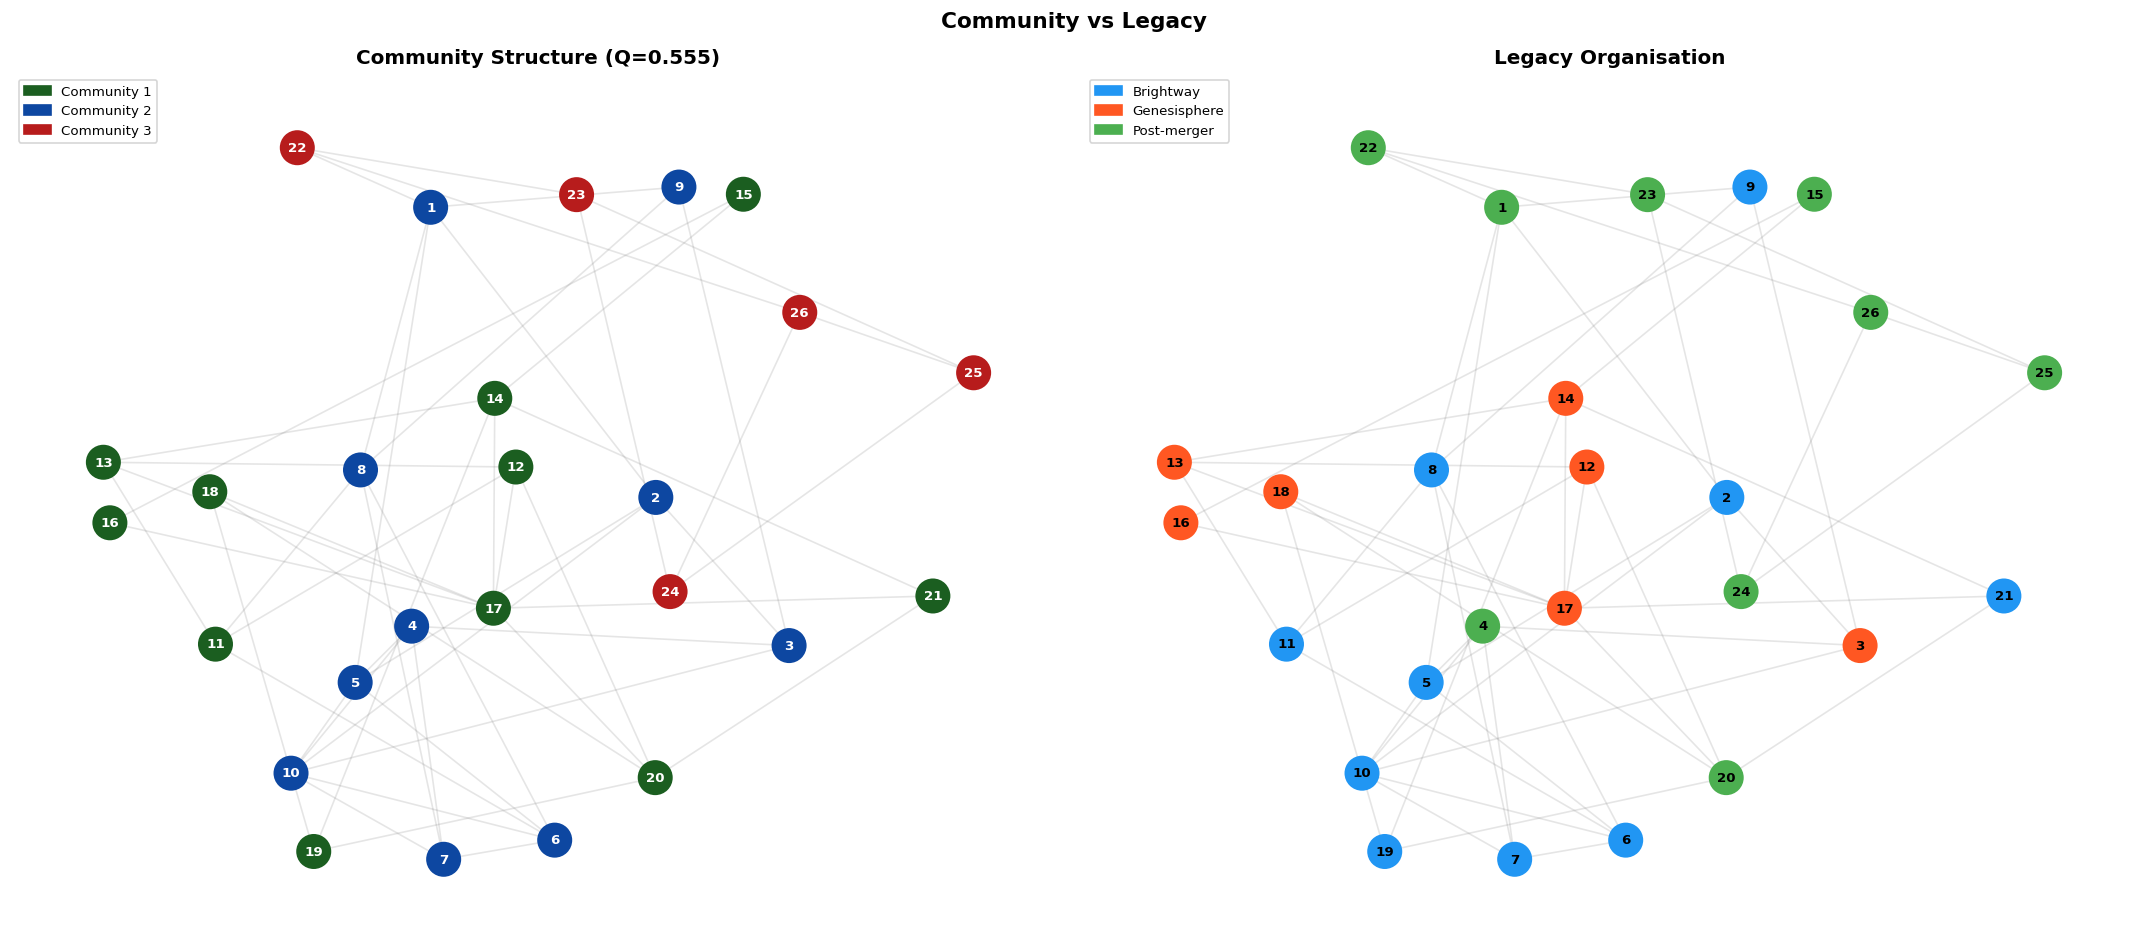

In [63]:
comm_map = {n: i for i, comm in enumerate(communities) for n in comm}
palette  = ['#1B5E20','#0D47A1','#B71C1C','#F57F17','#4A148C']
node_comm_colors = [palette[comm_map[n] % len(palette)] for n in G.nodes()]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# By community
nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color='grey', ax=axes[0])
nx.draw_networkx_nodes(G, pos, node_color=node_comm_colors, node_size=400, ax=axes[0])
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white', font_weight='bold', ax=axes[0])
axes[0].legend(handles=[mpatches.Patch(color=palette[i], label=f'Community {i+1}')
               for i in range(len(communities))], loc='upper left', fontsize=8)
axes[0].set_title(f'Community Structure (Q={modularity:.3f})', fontweight='bold')
axes[0].axis('off')

# By legacy
nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color='grey', ax=axes[1])
nx.draw_networkx_nodes(G, pos, node_color=node_color_list, node_size=400, ax=axes[1])
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=axes[1])
axes[1].legend(handles=[
    mpatches.Patch(color='#2196F3', label='Brightway'),
    mpatches.Patch(color='#FF5722', label='Genesisphere'),
    mpatches.Patch(color='#4CAF50', label='Post-merger'),
], loc='upper left', fontsize=8)
axes[1].set_title('Legacy Organisation', fontweight='bold')
axes[1].axis('off')

plt.suptitle('Community vs Legacy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('community_vs_legacy.png', bbox_inches='tight')
plt.show()

### 4.4 Articulation Points & Structural Holes

In [50]:
artic = sorted(nx.articulation_points(G))
print('Articulation points (removal disconnects network):', artic)

print('\nTop structural hole brokers (lowest Burt constraint):')
print(centrality_df.sort_values('Constraint')[
    ['Manager','Legacy_Organization','Brokerage_Orientation',
     'Betweenness','Constraint']
].head(10).round(4).to_string(index=False))

Articulation points (removal disconnects network): [1, 11, 22]

Top structural hole brokers (lowest Burt constraint):
 Manager Legacy_Organization Brokerage_Orientation  Betweenness  Constraint
      14        Genesisphere                    TI       0.1214      0.2848
       1         Post-merger                    TI       0.3556      0.2888
      17        Genesisphere                    TI       0.1586      0.3017
      22         Post-merger                    TG       0.2811      0.3333
       8           Brightway                    TG       0.3514      0.3339
       6           Brightway                    TI       0.1664      0.3609
       5           Brightway                    TG       0.0653      0.3617
       3        Genesisphere                    TG       0.0094      0.3733
      11           Brightway                    TG       0.5000      0.3753
      10           Brightway                    TG       0.0542      0.3983


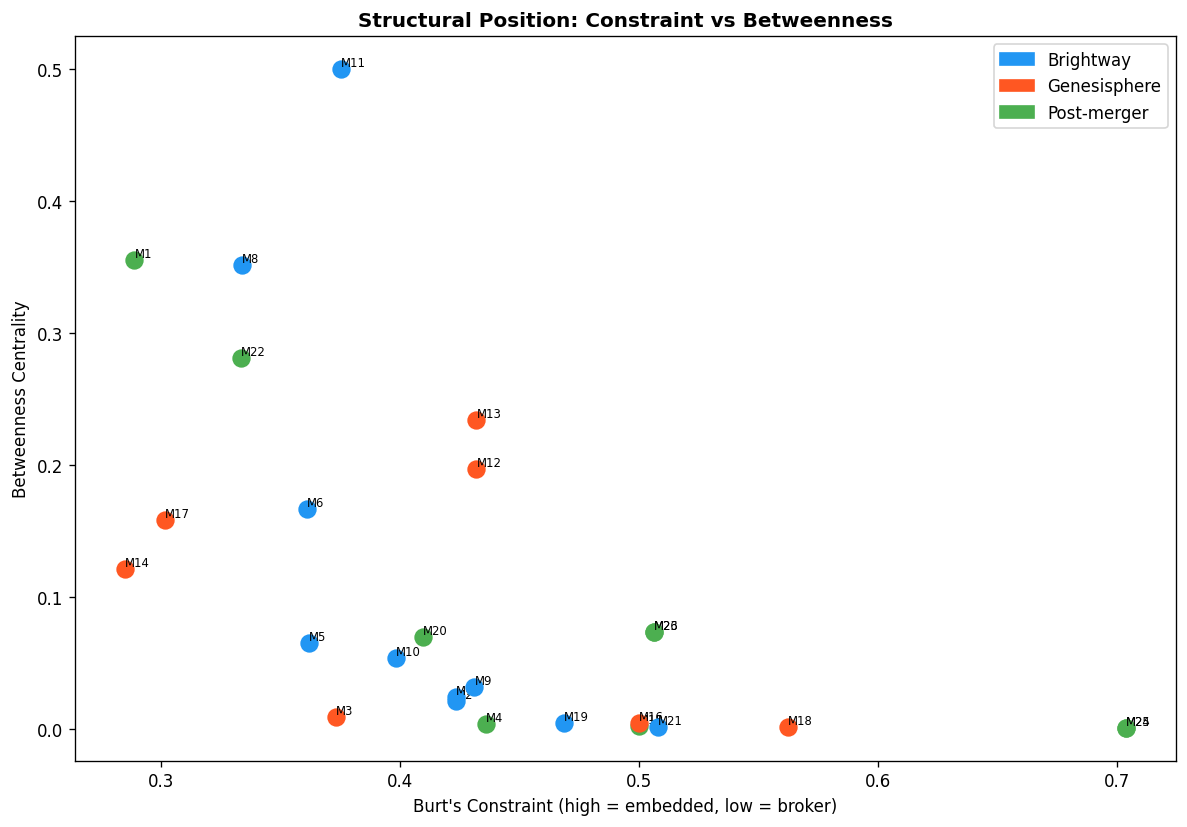

In [64]:
fig, ax = plt.subplots(figsize=(10, 7))
for _, row in centrality_df.iterrows():
    c = color_map_leg.get(row['Legacy_Organization'],'grey')
    ax.scatter(row['Constraint'], row['Betweenness'], color=c, s=100, zorder=3)
    ax.annotate(f"M{int(row['Manager'])}", (row['Constraint'], row['Betweenness']),
                fontsize=7, ha='left', va='bottom')
ax.set_xlabel("Burt's Constraint (high = embedded, low = broker)")
ax.set_ylabel('Betweenness Centrality')
ax.set_title('Structural Position: Constraint vs Betweenness', fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color='#2196F3', label='Brightway'),
    mpatches.Patch(color='#FF5722', label='Genesisphere'),
    mpatches.Patch(color='#4CAF50', label='Post-merger'),
])
plt.tight_layout()
plt.savefig('constraint_betweenness.png', bbox_inches='tight')
plt.show()

### 4.5 Suspected Saboteur Risk Analysis

In [65]:
risk = centrality_df.copy()
for col in ['Betweenness','Degree']:
    rng = risk[col].max() - risk[col].min()
    risk[col+'_n'] = (risk[col] - risk[col].min()) / rng if rng > 0 else 0

risk['against']  = (risk['Favor_Merger'] == 'N').astype(int)
risk['tg_flag']  = (risk['Brokerage_Orientation'] == 'TG').astype(int)
risk['Risk_Score'] = (
    risk['Betweenness_n'] * 0.40 +
    risk['Degree_n']      * 0.20 +
    risk['against']       * 0.30 +
    risk['tg_flag']       * 0.10
)

print('Highest-risk managers:')
print(risk.sort_values('Risk_Score', ascending=False)[
    ['Manager','Legacy_Organization','Favor_Merger','Brokerage_Orientation',
     'Degree','Betweenness','Risk_Score']
].head(10).round(3).to_string(index=False))

Highest-risk managers:
 Manager Legacy_Organization Favor_Merger Brokerage_Orientation  Degree  Betweenness  Risk_Score
      11           Brightway            N                    TG       4        0.500       0.880
       8           Brightway            N                    TG       5        0.351       0.801
      13        Genesisphere            N                    TI       4        0.234       0.567
      12        Genesisphere            N                    TI       4        0.197       0.537
      14        Genesisphere            N                    TI       5        0.121       0.516
       1         Post-merger          N/A                    TI       5        0.356       0.404
      22         Post-merger          N/A                    TG       3        0.281       0.364
      21           Brightway            N                    TI       3        0.002       0.341
      18        Genesisphere            N                    TI       3        0.002       0.341
      1

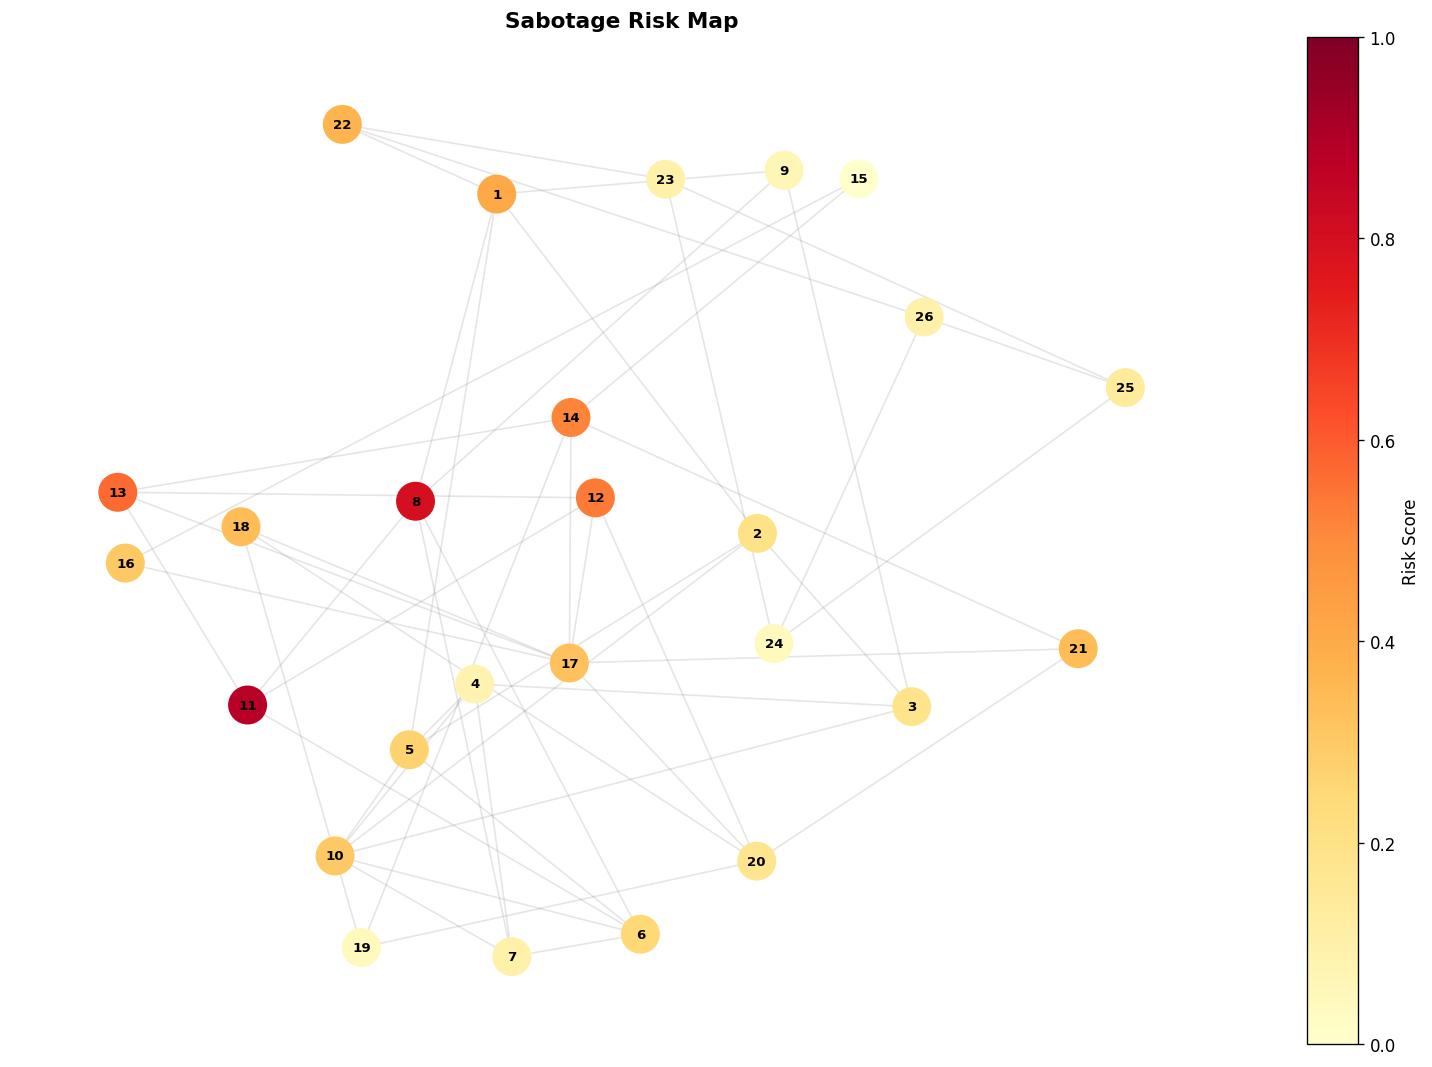

In [66]:
risk_map  = dict(zip(risk['Manager'], risk['Risk_Score']))
risk_vals = np.array([risk_map.get(n, 0) for n in G.nodes()])
cmap_r    = plt.cm.YlOrRd

fig, ax = plt.subplots(figsize=(13, 9))
nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color='grey', ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=risk_vals, cmap=cmap_r,
                       node_size=500, ax=ax, vmin=0, vmax=1)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)
sm = plt.cm.ScalarMappable(cmap=cmap_r, norm=plt.Normalize(0,1))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Risk Score')
ax.set_title('Sabotage Risk Map', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('risk_map.png', bbox_inches='tight')
plt.show()

## 5. Task Force Recommendation

In [67]:
tf = centrality_df.copy()
for col in ['Betweenness','Closeness','Self_Monitoring']:
    rng = tf[col].max() - tf[col].min()
    tf[col+'_n'] = (tf[col] - tf[col].min()) / rng if rng > 0 else 0

tf['ti_flag']  = (tf['Brokerage_Orientation'] == 'TI').astype(int)
tf['fav_flag'] = (tf['Favor_Merger'] == 'Y').astype(int)
tf['leg_val']  = tf['Legacy_Organization'].apply(lambda x: 1 if x in ['Brightway','Genesisphere'] else 0.5)

tf['TF_Score'] = (
    tf['Betweenness_n']    * 0.35 +
    tf['Closeness_n']      * 0.15 +
    tf['Self_Monitoring_n']* 0.15 +
    tf['ti_flag']          * 0.20 +
    tf['fav_flag']         * 0.10 +
    tf['leg_val']          * 0.05
)

# Select top 3 with cross-legacy diversity
selected, orgs_covered = [], set()
for _, row in tf.sort_values('TF_Score', ascending=False).iterrows():
    if len(selected) == 3: break
    org = row['Legacy_Organization']
    if org == 'None' and len(orgs_covered) < 2: continue
    selected.append(row)
    orgs_covered.add(org)

tf_final = pd.DataFrame(selected)
print('=== RECOMMENDED 3-PERSON TASK FORCE ===')
print(tf_final[['Manager','Legacy_Organization','Favor_Merger',
                'Brokerage_Orientation','Self_Monitoring',
                'Degree','Betweenness','TF_Score']].round(3).to_string(index=False))

=== RECOMMENDED 3-PERSON TASK FORCE ===
 Manager Legacy_Organization Favor_Merger Brokerage_Orientation  Self_Monitoring  Degree  Betweenness  TF_Score
       1         Post-merger          N/A                    TI                5       5        0.356     0.748
       6           Brightway            Y                    TI                4       5        0.166     0.707
      17        Genesisphere            Y                    TI                4       7        0.159     0.648


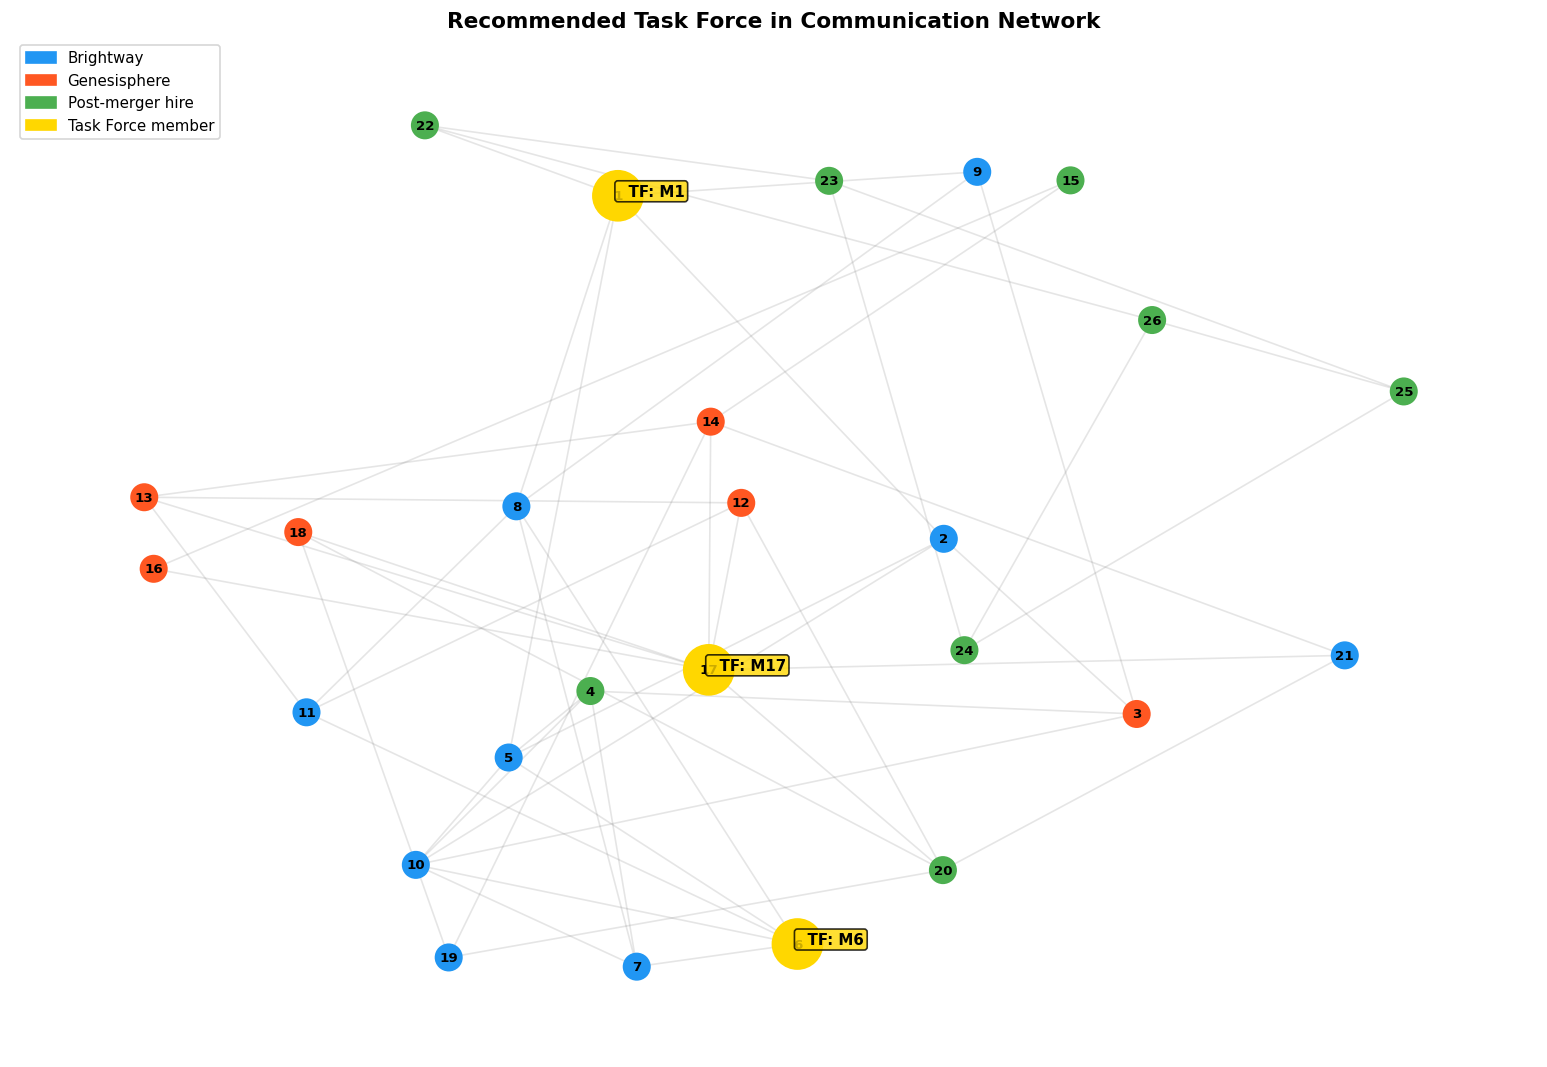

In [68]:
tf_ids = list(tf_final['Manager'].astype(int))

tf_node_colors = ['#FFD700' if n in tf_ids else node_color(n) for n in G.nodes()]
tf_node_sizes  = [900 if n in tf_ids else 250 for n in G.nodes()]

fig, ax = plt.subplots(figsize=(13, 9))
nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color='grey', ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=tf_node_colors, node_size=tf_node_sizes, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)

for mid in tf_ids:
    x, y = pos[mid]
    ax.annotate(f'  TF: M{mid}', xy=(x,y), fontsize=9, fontweight='bold', color='black',
                bbox=dict(boxstyle='round,pad=0.2', fc='#FFD700', alpha=0.8))

ax.legend(handles=[
    mpatches.Patch(color='#2196F3', label='Brightway'),
    mpatches.Patch(color='#FF5722', label='Genesisphere'),
    mpatches.Patch(color='#4CAF50', label='Post-merger hire'),
    mpatches.Patch(color='#FFD700', label='Task Force member'),
], loc='upper left', fontsize=9)
ax.set_title('Recommended Task Force in Communication Network',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('task_force.png', bbox_inches='tight')
plt.show()

## 6. Full Summary

In [56]:
print('=== NETWORK STATISTICS ===')
Gcc = G.subgraph(max(nx.connected_components(G), key=len))
print(f'Nodes: {G.number_of_nodes()}')
print(f'Edges (undirected): {G.number_of_edges()}')
print(f'Density: {nx.density(G):.4f}')
print(f'Avg degree: {np.mean(list(dict(G.degree()).values())):.2f}')
print(f'Avg clustering coefficient: {nx.average_clustering(G):.4f}')
print(f'Avg shortest path (main component): {nx.average_shortest_path_length(Gcc):.4f}')
print(f'Diameter: {nx.diameter(Gcc)}')
print(f'Communities (greedy modularity): {len(communities)}')
print(f'Modularity Q: {modularity:.4f}')

=== NETWORK STATISTICS ===
Nodes: 26
Edges (undirected): 51
Density: 0.1569
Avg degree: 3.92
Avg clustering coefficient: 0.3777
Avg shortest path (main component): 3.5938
Diameter: 8
Communities (greedy modularity): 3
Modularity Q: 0.5554


In [57]:
print('=== FULL MANAGER TABLE ===')
print(centrality_df[['Manager','Legacy_Organization','Favor_Merger',
                      'Brokerage_Orientation','Self_Monitoring',
                      'Degree','Betweenness','Closeness',
                      'Constraint','events_attended']]
      .sort_values('Manager').round(4).to_string(index=False))

=== FULL MANAGER TABLE ===
 Manager Legacy_Organization Favor_Merger Brokerage_Orientation  Self_Monitoring  Degree  Betweenness  Closeness  Constraint  events_attended
       1         Post-merger          N/A                    TI                5       5       0.3556     0.3571      0.2888                3
       2           Brightway            Y                    TG                2       4       0.0211     0.2907      0.4232                1
       3        Genesisphere            Y                    TG                1       4       0.0094     0.2747      0.3733                2
       4         Post-merger          N/A                    TI                3       4       0.0039     0.2747      0.4358                1
       5           Brightway            Y                    TG                4       5       0.0653     0.3378      0.3617                2
       6           Brightway            Y                    TI                4       5       0.1664     0.3623      0.3